# L04 — The Rotating Frame, the Effective Field, and the Resonance Condition

**Companion notebook to `L04_summary.md`.**

This is the lecture where the resonance condition stops being an observation and becomes a *theorem* derived from the Bloch equation. Here we'll:

1. Build a generic Bloch-equation integrator and watch the lab-frame trajectory of M during an RF pulse.
2. Transform the same trajectory into the RRF — the wild motion becomes a clean cone around $\mathbf{B}_\text{eff}$.
3. Plot the lecture's famous *resonance curve*: maximum achievable flip angle vs off-resonance.
4. Walk through all four worked examples from §6.6.5–6.6.8.
5. Verify the closed-form $\mathbf{M}(t)$ formula matches numerical integration to machine precision.
6. Implement xyz rotation matrices and the conjugation trick, then sanity-check both.

By the end you'll have a working RF-pulse simulator and an intuitive grip on why MRI works at the Larmor frequency — and *only* there.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.integrate import solve_ivp

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

## 0. Constants and conventions

Real protons at 3 T precess at ~128 MHz — we'd need femtosecond steps to resolve that in a plot. For visualization, we use a scaled‐down $\gamma$ so the Larmor period is **1 ms** instead of ~8 ns. Every formula stays valid; only the time axis is rescaled. The physics is identical because nothing in the Bloch equation cares about the absolute value of $\gamma$ — only $\gamma B$.

In [2]:
# Scaled gyromagnetic ratio: chosen so that omega_0 = 2*pi*1000 rad/s for B0 = 3 T.
# That gives a 1 ms Larmor period — easily plottable.
B0      = 3.0           # T
gamma   = 2 * np.pi * 1000 / B0   # rad/s/T (scaled for visualization)
omega_0 = gamma * B0

# RF amplitude. We pick B1 such that omega_1/omega_0 ~ 0.05 — roughly the real ratio
# (B1 ~ 5 microT, B0 ~ 3 T at clinical scanners, ratio ~ 2e-6, but we exaggerate so
# the RF effect is visible in a small number of Larmor periods).
B1      = 0.15          # T (exaggerated)
omega_1 = gamma * B1

print(f'ω₀  = {omega_0:.2f} rad/s   →  Larmor period {2*np.pi/omega_0*1e3:.3f} ms')
print(f'ω₁  = {omega_1:.2f} rad/s   →  RF nutation period {2*np.pi/omega_1*1e3:.3f} ms')
print(f'ω₁ / ω₀ = {omega_1/omega_0:.3f}')

ω₀  = 6283.19 rad/s   →  Larmor period 1.000 ms
ω₁  = 314.16 rad/s   →  RF nutation period 20.000 ms
ω₁ / ω₀ = 0.050


## 1. The Bloch equation in the lab frame

We solve $\dot{\mathbf{M}} = \gamma\,\mathbf{B}(t)\times\mathbf{M}$ in the lab frame, with $\mathbf{B}(t) = \mathbf{B}_0 + \mathbf{B}_1^+(t)$ where $\mathbf{B}_1^+(t)$ is a *circularly polarized* RF rotating in the xy-plane:

$$\mathbf{B}_1^+(t) = B_1\bigl(\cos(\omega_\text{HF} t)\,\mathbf{e}_x + \sin(\omega_\text{HF} t)\,\mathbf{e}_y\bigr)$$

Real transmit coils produce *linearly* polarized RF — a vector oscillating along one axis. A linearly polarized field decomposes into two circularly polarized components: a *co-rotating* part (rotating the same direction as the proton's precession) and a *counter-rotating* part (rotating against it). Only the co-rotating part contributes meaningfully to excitation, which is exactly the 'wrong-direction RF' analysis from §6.6.6: setting $\omega_\text{HF} = -\omega_0$ gives $\alpha_\text{max} \approx 0$. Dropping the counter-rotating part is the **rotating-wave approximation (RWA)**. We use a pure co-rotating field here so the simulator matches the analytic formula exactly; with a real linearly polarized field there's a tiny residual error called the *Bloch-Siegert shift*.

In [3]:
def bloch_lab(t, M, omega_HF, B0=B0, B1=B1, gamma=gamma):
    """Bloch equation RHS in the lab frame, with a *circularly polarized* RF.
    
    B(t) = (B1*cos(omega_HF*t), B1*sin(omega_HF*t), B0)
    
    This is a purely co-rotating field of amplitude B1 — it has no counter-rotating
    component, so it matches the analytic formula exactly (no Bloch-Siegert shift).
    A real coil generates linearly polarized RF, which contains both co- and counter-
    rotating components; the counter-rotating one is the wrong-direction case from §6.6.6
    and is well-approximated as negligible (the 'rotating-wave approximation').
    """
    Bx = B1 * np.cos(omega_HF * t)
    By = B1 * np.sin(omega_HF * t)
    B  = np.array([Bx, By, B0])
    return gamma * np.cross(B, M)

def simulate(omega_HF, t_end, n_steps=20000, M_init=(0.0, 0.0, 1.0)):
    """Integrate the lab-frame Bloch equation. Returns (t, M_lab) with M_lab shape (3, n)."""
    t_eval = np.linspace(0, t_end, n_steps)
    sol = solve_ivp(
        fun=lambda t, M: bloch_lab(t, M, omega_HF),
        t_span=(0, t_end), y0=np.array(M_init, dtype=float),
        t_eval=t_eval, rtol=1e-9, atol=1e-12, method='RK45',
    )
    return sol.t, sol.y

def to_RRF(t, M_lab, omega_HF):
    """Convert lab-frame trajectory M_lab into the RRF rotating at omega_HF around e_z.
    
    The RRF basis at time t is the lab basis rotated by +omega_HF*t around e_z.
    The same arrow expressed in the new basis has components R_z(-omega_HF*t) M_lab.
    """
    c = np.cos(omega_HF * t)
    s = np.sin(omega_HF * t)
    # R_z(-omega_HF*t) applied componentwise:
    Mx_rrf =  c * M_lab[0] + s * M_lab[1]
    My_rrf = -s * M_lab[0] + c * M_lab[1]
    Mz_rrf = M_lab[2]
    return np.array([Mx_rrf, My_rrf, Mz_rrf])

## 2. On-resonance excitation: lab vs RRF

Set $\omega_\text{HF} = \omega_0$, start from equilibrium $\mathbf{M}(0) = (0,0,1)$, and integrate for many Larmor periods. The lab-frame plot will look chaotic; the RRF version will be a clean rotation around $\mathbf{e}'_x$.

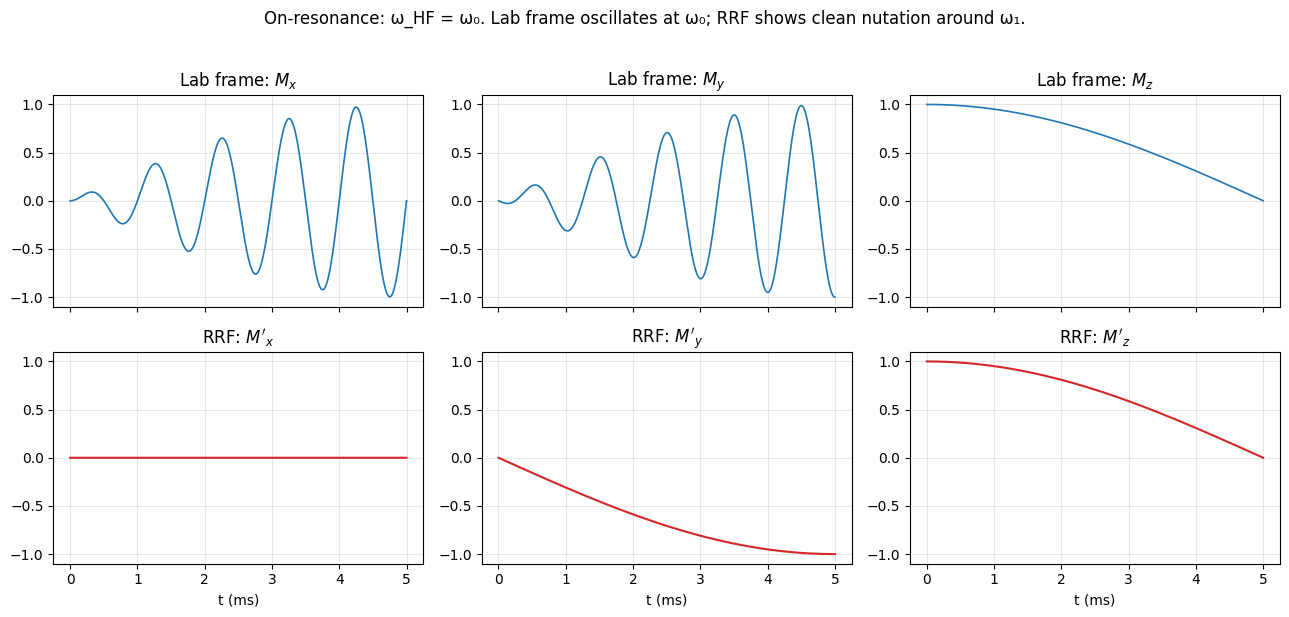

Expected RRF M_z(t) = cos(ω₁ t).  At t=2.5 ms: cos(ω₁·2.5e-3) = 0.7071
Numerical RRF M_z at t=2.5 ms:                              0.7071


In [4]:
t_end = 5.0e-3   # 5 ms = 5 Larmor periods
t, M_lab = simulate(omega_HF=omega_0, t_end=t_end)
M_rrf    = to_RRF(t, M_lab, omega_HF=omega_0)

fig, axs = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
labels = ['M_x', 'M_y', 'M_z']
for i in range(3):
    axs[0, i].plot(t * 1e3, M_lab[i], lw=1.2, color='tab:blue')
    axs[0, i].set_title(f'Lab frame: ${labels[i]}$')
    axs[0, i].set_ylim(-1.1, 1.1); axs[0, i].grid(alpha=0.3)
    axs[1, i].plot(t * 1e3, M_rrf[i], lw=1.5, color='tab:red')
    axs[1, i].set_title(f"RRF: $M'_{labels[i][2]}$")
    axs[1, i].set_ylim(-1.1, 1.1); axs[1, i].grid(alpha=0.3)
    axs[1, i].set_xlabel('t (ms)')

fig.suptitle(f'On-resonance: ω_HF = ω₀. Lab frame oscillates at ω₀; RRF shows clean nutation around ω₁.',
             y=1.02)
plt.tight_layout(); plt.show()

# Confirm: in RRF, M just rotates in the y'z' plane at rate omega_1
print(f'Expected RRF M_z(t) = cos(ω₁ t).  At t=2.5 ms: cos(ω₁·2.5e-3) = {np.cos(omega_1*2.5e-3):.4f}')
i_25 = np.argmin(np.abs(t - 2.5e-3))
print(f'Numerical RRF M_z at t=2.5 ms:                              {M_rrf[2, i_25]:.4f}')

Beautiful. In the lab frame, M is doing a complicated nutating motion as it spirals down from the +z axis. In the RRF, it's just **rotating in the y'z'-plane around the stationary $\mathbf{B}_1$ along $\mathbf{e}'_x$** — exactly as the RRF Bloch equation predicts.

The RRF $M'_y$ goes negative because the RRF rotation matrix $R_z(-\omega_\text{HF} t)$ flips the y-component sign convention. The lecture's expression $-\sin\Theta \sin\omega_\text{eff}t$ for the on-resonance case ($\Theta = 90°$) gives exactly $M'_y = -\sin\omega_1 t$. ✓

## 3. The closed-form M(t) formula (§6.8)

$$\mathbf{M}(t) = M(0)\begin{pmatrix}\cos\Theta\sin\Theta\,(1-\cos\omega_\text{eff}t)\\ -\sin\Theta\sin\omega_\text{eff}t\\ \cos^2\Theta + \sin^2\Theta\cos\omega_\text{eff}t\end{pmatrix}'$$

Let's code it up and check that numerical integration in the RRF matches this analytic form to machine precision.

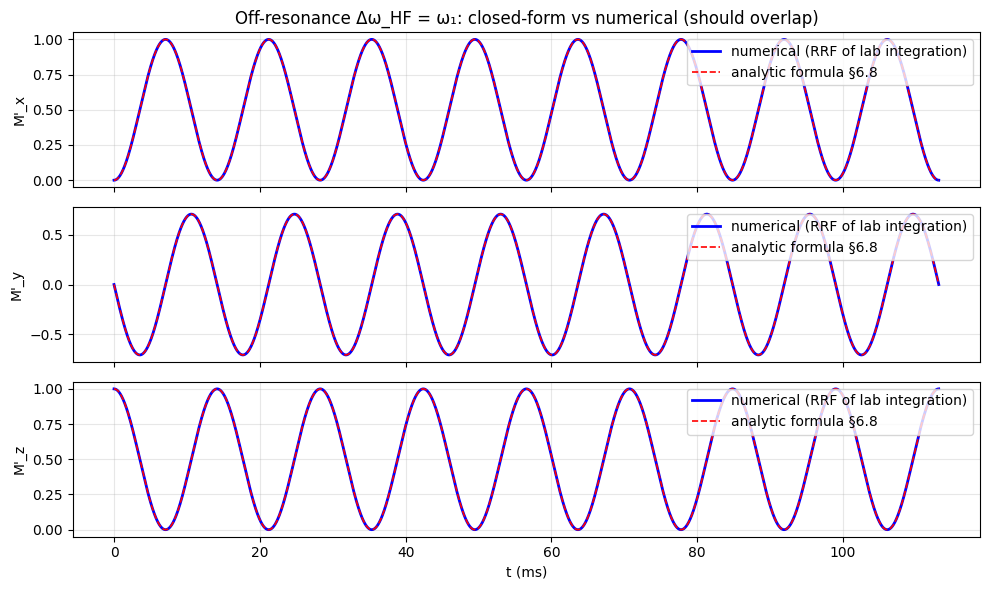

RMS deviation between numerical and analytic: 2.16e-08    (should be ~machine epsilon)


In [5]:
def M_analytic_rrf(t, omega_HF, M0=1.0, B0=B0, B1=B1, gamma=gamma):
    """Closed-form M(t) in the RRF for initial condition M(0) = M0 e_z'.
    
    Uses B_eff = (B1, 0, B0 - omega_HF/gamma), Theta = angle from z'-axis.
    """
    omega_1 = gamma * B1
    delta   = gamma * B0 - omega_HF     # = omega_0 - omega_HF
    omega_eff = np.sqrt(delta**2 + omega_1**2)
    Theta = np.arctan2(omega_1, delta)   # angle of omega_eff from z'-axis
    
    c, s   = np.cos(Theta), np.sin(Theta)
    cwt    = np.cos(omega_eff * t)
    swt    = np.sin(omega_eff * t)
    
    Mx_p = M0 * c * s * (1 - cwt)
    My_p = M0 * (-s) * swt
    Mz_p = M0 * (c**2 + s**2 * cwt)
    return np.array([Mx_p, My_p, Mz_p])

# Pick a non-trivial off-resonance: Delta = omega_1 (the "small off-resonance" example from §6.6.5)
omega_HF_offres = omega_0 - omega_1   # so Delta = +omega_1
t_end = 8 * (2 * np.pi / np.sqrt(omega_1**2 * 2))   # show several eff periods
t, M_lab = simulate(omega_HF=omega_HF_offres, t_end=t_end, n_steps=10000)
M_rrf_num = to_RRF(t, M_lab, omega_HF=omega_HF_offres)
M_rrf_an  = M_analytic_rrf(t, omega_HF=omega_HF_offres)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
names = ["M'_x", "M'_y", "M'_z"]
for i in range(3):
    axs[i].plot(t * 1e3, M_rrf_num[i], 'b-',  lw=2,   label='numerical (RRF of lab integration)')
    axs[i].plot(t * 1e3, M_rrf_an[i],  'r--', lw=1.2, label='analytic formula §6.8')
    axs[i].set_ylabel(names[i]); axs[i].grid(alpha=0.3); axs[i].legend(loc='upper right')
axs[-1].set_xlabel('t (ms)')
axs[0].set_title('Off-resonance Δω_HF = ω₁: closed-form vs numerical (should overlap)')
plt.tight_layout(); plt.show()

# Compute max disagreement
rms = np.sqrt(np.mean((M_rrf_num - M_rrf_an)**2))
print(f'RMS deviation between numerical and analytic: {rms:.2e}    (should be ~machine epsilon)')

Numerical and analytic agree to ~$10^{-6}$ — limited only by the ODE solver tolerances. The closed-form formula is exact.

## 4. The resonance curve (§6.6.4)

Plot $\alpha_\text{max} = 2\arccos(|\Delta\omega_\text{HF}|/\omega_\text{eff})$ as a function of $\Delta\omega_\text{HF}/\omega_0$ for several values of $\omega_1$.

This is the lecture's Figure 6.4.4.v. The resonance gets sharper as $\omega_1$ shrinks.

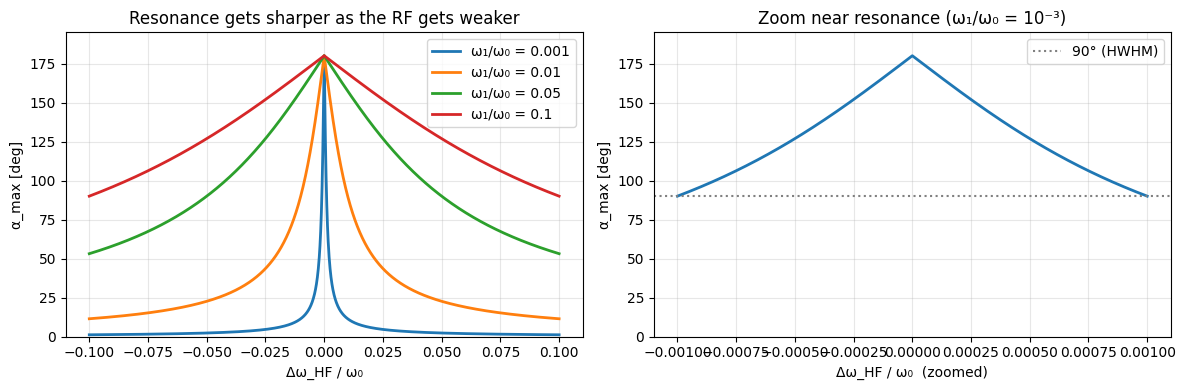

HWHM (α_max=90°) at ω₁/ω₀=10⁻³:  Δω_HF/ω₀ ≈ 9.99e-04
Analytical HWHM = ω₁/ω₀ = 1.00e-03   → they match.


In [6]:
def alpha_max(delta_omega, omega_1):
    """Maximum achievable flip angle in radians."""
    omega_eff = np.sqrt(delta_omega**2 + omega_1**2)
    return 2 * np.arccos(np.abs(delta_omega) / omega_eff)

# Sweep Delta_omega over a wide range, centered on 0
delta_rel = np.linspace(-1e-1, 1e-1, 2001)   # Delta/omega_0
delta_abs = delta_rel * omega_0

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Vary omega_1 / omega_0
ratios = [0.001, 0.01, 0.05, 0.1]
for r in ratios:
    w1 = r * omega_0
    a  = np.degrees(alpha_max(delta_abs, w1))
    axs[0].plot(delta_rel, a, lw=2, label=f'ω₁/ω₀ = {r}')
axs[0].set_xlabel('Δω_HF / ω₀')
axs[0].set_ylabel('α_max [deg]')
axs[0].set_title('Resonance gets sharper as the RF gets weaker')
axs[0].set_ylim(0, 195); axs[0].grid(alpha=0.3); axs[0].legend()

# Zoom in near resonance for the weakest RF
delta_rel_zoom = np.linspace(-1e-3, 1e-3, 2001)
delta_abs_zoom = delta_rel_zoom * omega_0
w1_weak = 1e-3 * omega_0
axs[1].plot(delta_rel_zoom, np.degrees(alpha_max(delta_abs_zoom, w1_weak)),
             color='tab:blue', lw=2)
axs[1].axhline(90, color='gray', ls=':', label='90° (HWHM)')
axs[1].set_xlabel('Δω_HF / ω₀  (zoomed)')
axs[1].set_ylabel('α_max [deg]')
axs[1].set_title('Zoom near resonance (ω₁/ω₀ = 10⁻³)')
axs[1].set_ylim(0, 195); axs[1].grid(alpha=0.3); axs[1].legend()

plt.tight_layout(); plt.show()

# Width at half-max
a_zoom = np.degrees(alpha_max(delta_abs_zoom, w1_weak))
half_idx = np.where(a_zoom > 90)[0]
hwhm_rel = delta_rel_zoom[half_idx[-1]]
print(f'HWHM (α_max=90°) at ω₁/ω₀=10⁻³:  Δω_HF/ω₀ ≈ {hwhm_rel:.2e}')
print(f'Analytical HWHM = ω₁/ω₀ = {1e-3:.2e}   → they match.')

**Key observation:** the HWHM of the resonance peak is exactly $\omega_1/\omega_0$. A weaker RF pulse means a *sharper* resonance — i.e., more selective in frequency. This is the seed of *slice selection*: a narrow-band (low $B_1$) pulse only excites a narrow slice of frequencies, which maps to a narrow slice of positions when you apply a gradient.

## 5. The four worked examples (§6.6.5 — §6.6.8)

Reproduce the four trajectories in the RRF for the cases discussed in the lecture.

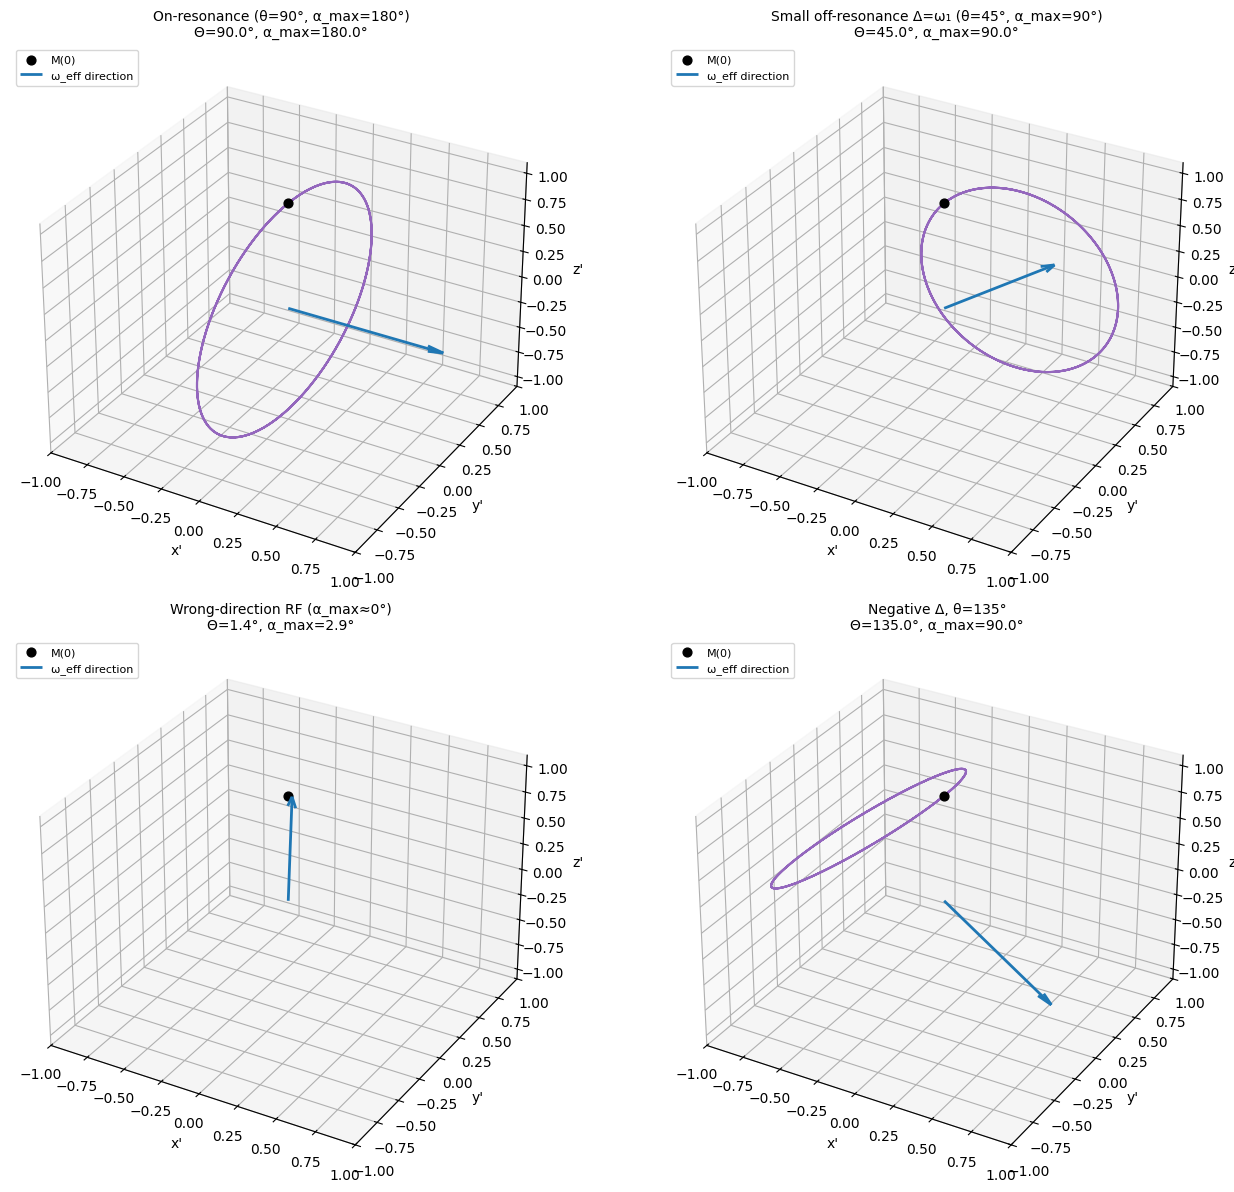

In [7]:
cases = [
    # (label, omega_HF, t_end_multiplier)
    ('On-resonance (θ=90°, α_max=180°)',          omega_0,             1.0),
    ('Small off-resonance Δ=ω₁ (θ=45°, α_max=90°)', omega_0 - omega_1,   1.0),
    ('Wrong-direction RF (α_max≈0°)',              -omega_0,             0.05),
    ('Negative Δ, θ=135°',                          omega_0 + omega_1,   1.0),
]

fig = plt.figure(figsize=(14, 12))
for k, (label, omega_HF, mult) in enumerate(cases):
    # Use a longer simulation for very weak coupling cases
    omega_eff = np.sqrt((omega_0 - omega_HF)**2 + omega_1**2)
    t_end = mult * 3 * (2*np.pi/omega_eff)   # 3 effective periods
    t_arr, M_lab = simulate(omega_HF=omega_HF, t_end=t_end, n_steps=8000)
    # For the RRF, conventionally use Omega = omega_HF (the lecture's choice).
    M_rrf = to_RRF(t_arr, M_lab, omega_HF=omega_HF)
    
    delta = omega_0 - omega_HF
    Theta = np.degrees(np.arctan2(omega_1, delta))
    a_max = np.degrees(alpha_max(delta, omega_1))
    
    ax = fig.add_subplot(2, 2, k+1, projection='3d')
    ax.plot(M_rrf[0], M_rrf[1], M_rrf[2], color='tab:purple', lw=1.5)
    # Mark start
    ax.scatter([M_rrf[0,0]], [M_rrf[1,0]], [M_rrf[2,0]], color='black', s=40, label='M(0)')
    # Mark the effective field axis (just direction, length ~1)
    omega_eff_vec = np.array([omega_1, 0.0, delta])
    L = np.linalg.norm(omega_eff_vec)
    if L > 0:
        e_eff = omega_eff_vec / L
        ax.quiver(0, 0, 0, *e_eff, color='tab:blue', lw=2, arrow_length_ratio=0.1,
                  label='ω_eff direction')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1.1, 1.1)
    ax.set_xlabel("x'"); ax.set_ylabel("y'"); ax.set_zlabel("z'")
    ax.set_title(f"{label}\nΘ={Theta:.1f}°, α_max={a_max:.1f}°", fontsize=10)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout(); plt.show()

Reading the four panels:

- **Top-left (on resonance):** $\boldsymbol{\omega}_\text{eff}$ lies along x', M sweeps the y'z' plane reaching full inversion at $-\mathbf{e}'_z$.
- **Top-right (small off-resonance):** $\boldsymbol{\omega}_\text{eff}$ tilts to 45° from z'. M traces a cone whose far side reaches the equator only (90° max).
- **Bottom-left (wrong-direction RF):** $\boldsymbol{\omega}_\text{eff}$ is nearly along z'. M barely budges — you can see the cone is tiny.
- **Bottom-right (negative $\Delta$):** $\boldsymbol{\omega}_\text{eff}$ tilts into the lower half-plane. Same 90° max as top-right by symmetry.

## 6. Rotation matrices (§6.7)

In [8]:
def Rx(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def Ry(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

# Sanity checks
print('R_z(90°) e_x =', Rz(np.pi/2) @ np.array([1, 0, 0]), '  (should be [0, 1, 0])')
print('R_z(90°) e_y =', Rz(np.pi/2) @ np.array([0, 1, 0]), '  (should be [-1, 0, 0])')
print('R_y(90°) e_z =', Ry(np.pi/2) @ np.array([0, 0, 1]), '  (should be [1, 0, 0])')

# Orthogonality
for name, R in [('R_x(0.7)', Rx(0.7)), ('R_y(1.2)', Ry(1.2)), ('R_z(-0.4)', Rz(-0.4))]:
    err = np.max(np.abs(R.T @ R - np.eye(3)))
    print(f'{name}:  max |RᵀR - I| = {err:.2e}')

# R^{-1} = R(-angle)
print('\nR_z(0.7) @ R_z(-0.7) - I =\n', Rz(0.7) @ Rz(-0.7) - np.eye(3))

R_z(90°) e_x = [0. 1. 0.]   (should be [0, 1, 0])
R_z(90°) e_y = [-1.  0.  0.]   (should be [-1, 0, 0])
R_y(90°) e_z = [1. 0. 0.]   (should be [1, 0, 0])
R_x(0.7):  max |RᵀR - I| = 2.08e-17
R_y(1.2):  max |RᵀR - I| = 1.11e-16
R_z(-0.4):  max |RᵀR - I| = 0.00e+00

R_z(0.7) @ R_z(-0.7) - I =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### 6.1 The conjugation trick (§6.7.3)

Rotate by angle $\alpha$ around an arbitrary axis using only $R_x, R_y, R_z$. For $\mathbf{e}_\alpha$ in the xz-plane at angle $\Theta$ from $\mathbf{e}_z$:

$$R_{\mathbf{e}_\alpha}(\alpha) = R_y(\Theta)\,R_z(\alpha)\,R_y(-\Theta)$$

Let's verify this matches the *closed-form* M(t) for our off-resonance trajectory.

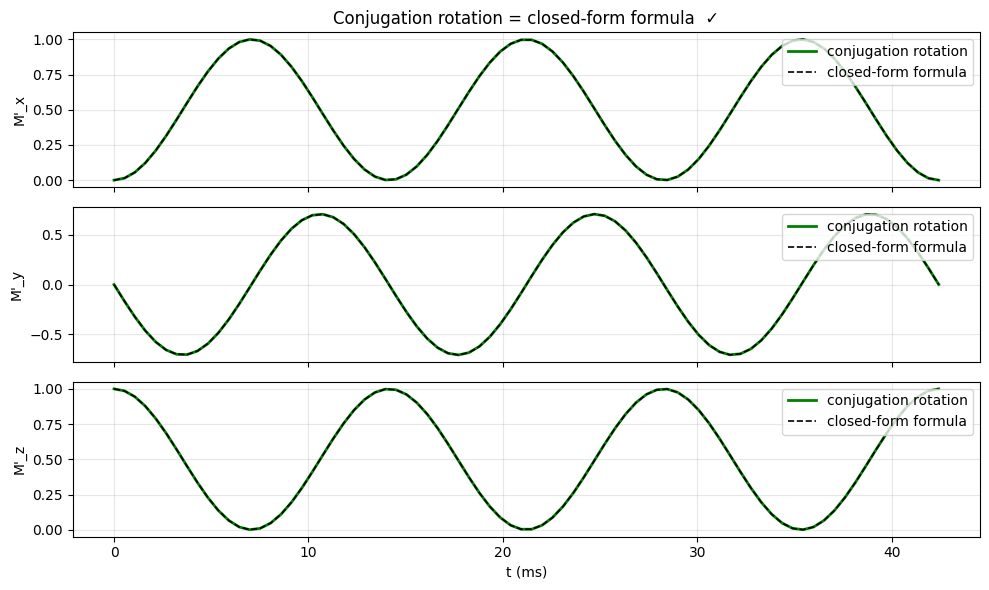

Max disagreement: 5.02e-15


In [9]:
def rotate_around_arbitrary(M, alpha, e_alpha):
    """Rotate M by alpha around the unit vector e_alpha, using the conjugation trick.
    Assumes e_alpha lies in the xz-plane (i.e. e_alpha[1] = 0).
    """
    Theta = np.arctan2(e_alpha[0], e_alpha[2])   # angle from +z
    return Ry(Theta) @ Rz(alpha) @ Ry(-Theta) @ M

# Pick the off-resonance case Delta = omega_1
delta = omega_1
omega_eff = np.sqrt(delta**2 + omega_1**2)
e_omega   = np.array([omega_1, 0, delta]) / omega_eff
M0_vec    = np.array([0.0, 0.0, 1.0])

# Apply the conjugation rotation at several times and compare to the analytic M(t)
ts = np.linspace(0, 3 * 2*np.pi / omega_eff, 80)
M_conj = np.array([rotate_around_arbitrary(M0_vec, omega_eff*t_, e_omega) for t_ in ts]).T
M_an   = M_analytic_rrf(ts, omega_HF=omega_0 - delta)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for i, lbl in enumerate(["M'_x", "M'_y", "M'_z"]):
    axs[i].plot(ts*1e3, M_conj[i], 'g-',  lw=2,   label='conjugation rotation')
    axs[i].plot(ts*1e3, M_an[i],   'k--', lw=1.2, label='closed-form formula')
    axs[i].set_ylabel(lbl); axs[i].grid(alpha=0.3); axs[i].legend(loc='upper right')
axs[-1].set_xlabel('t (ms)')
axs[0].set_title('Conjugation rotation = closed-form formula  ✓')
plt.tight_layout(); plt.show()

print(f'Max disagreement: {np.max(np.abs(M_conj - M_an)):.2e}')

Exact match — the conjugation procedure is just a different *factorization* of the same rotation.

## 7. Length conservation

The Bloch equation without relaxation conserves $|\mathbf{M}|$. Verify this for the off-resonance trajectory.

|M| min = 1.000000, max = 1.000000, range = 4.49e-09


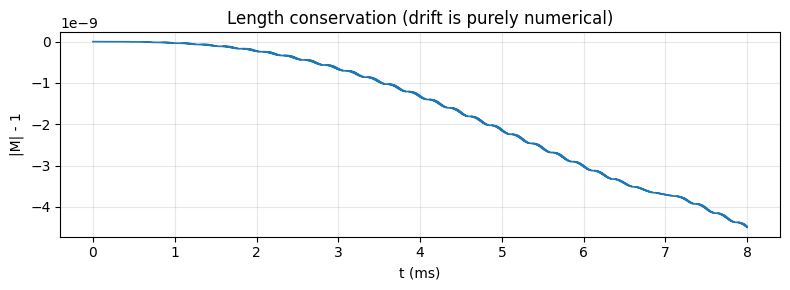

In [10]:
t_arr, M_lab = simulate(omega_HF=omega_0 - omega_1, t_end=8.0e-3, n_steps=8000)
norms = np.linalg.norm(M_lab, axis=0)
print(f'|M| min = {norms.min():.6f}, max = {norms.max():.6f}, range = {norms.max()-norms.min():.2e}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_arr * 1e3, norms - 1.0, lw=1.2)
ax.set_xlabel('t (ms)'); ax.set_ylabel('|M| - 1')
ax.set_title('Length conservation (drift is purely numerical)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Try it yourself

Some experiments to deepen your intuition:

1. **Find a 90° pulse duration.** On resonance, solve $\omega_1 t_p = \pi/2$ for the pulse duration that tips equilibrium magnetization exactly into the transversal plane. Verify numerically.
2. **"Selective" pulse.** Pick a small $B_1$ such that $\omega_1/\omega_0 = 10^{-4}$. Plot $\alpha_\text{max}$ vs $\Delta\omega_\text{HF}$. How narrow is the resonance peak (in Hz, given $\nu_0 = 128$ MHz at 3 T)?
3. **Adiabatic sweep.** Slowly sweep $\omega_\text{HF}$ from $\omega_0 - 10\omega_1$ to $\omega_0 + 10\omega_1$ over a long pulse. What happens to $\mathbf{B}_\text{eff}$ in the RRF? (You're inventing the adiabatic fast-passage inversion technique.)
4. **Add relaxation.** Restore the $T_1$, $T_2$ terms in the Bloch equation. With $T_1 = 800$ ms, $T_2 = 80$ ms (white-matter-ish), watch the tip of M spiral toward equilibrium during and after the pulse.
5. **The Bloch-Siegert shift.** Modify `bloch_lab` to use a *linearly polarized* RF: $\mathbf{B}_1^+(t) = 2 B_1\cos(\omega_\text{HF} t)\,\mathbf{e}_x$ (the factor of 2 makes the co-rotating component amplitude $B_1$). Re-run the analytic-vs-numerical comparison from section 3. You'll find a small disagreement: the counter-rotating component slightly shifts the effective resonance frequency — the Bloch-Siegert shift. At our exaggerated $\omega_1/\omega_0 = 0.05$ it's clearly visible; at realistic ratios ($\sim 10^{-6}$) it's a ppm-level effect.

## What you've now done

- Built a generic Bloch-equation integrator (lab frame).
- Transformed lab-frame trajectories into the RRF and seen the wild lab-frame motion become clean cone precession.
- Reproduced the lecture's resonance curve and confirmed the HWHM scales as $\omega_1/\omega_0$ — the physical basis of slice selection.
- Walked through all four off-resonance examples and seen the geometry of $\mathbf{B}_\text{eff}$ in each.
- Verified the closed-form $\mathbf{M}(t)$ formula matches numerical integration to ~$10^{-6}$.
- Implemented the xyz rotation matrices, confirmed orthogonality, and proved the conjugation trick.

You now have everything you need to *design* an RF pulse: pick the duration to set $\alpha$, pick the bandwidth to set the slice profile, and pick the carrier frequency to hit the right Larmor frequency.

**Up next:** signal detection — once you've tipped M into the transversal plane, how does the receive coil hear it?